# 06 - Baseline Defect Detection

This notebook builds a simple defect detection baseline before the professional Anomalib model.

The baseline answers one question:

**Input image -> good or defective?**

## Why Build A Baseline?

A baseline is useful because it:

- confirms the dataset loader works
- confirms preprocessing works
- gives early evaluation metrics
- creates a simple heatmap idea
- gives us something to compare against Anomalib later

This baseline is not the final model. The final professional model will use Anomalib/PyTorch.

## Baseline Idea

1. Use only `train/good` images.
2. Preprocess each good image.
3. Build an average **normal reference image**.
4. For each test image, calculate difference from the reference image.
5. Convert difference to an anomaly score.
6. If score is above threshold -> defective.
7. Evaluate predictions on test images.

This works only if images are reasonably aligned. MVTec bottle images are aligned enough for a useful baseline.

In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml.baseline_detector import (
    anomaly_map,
    anomaly_score,
    build_reference_image,
    evaluate_binary_predictions,
    heatmap_overlay,
    load_image_bgr,
    predict_from_score,
    score_dataframe,
    threshold_from_scores,
)
from ml.dataset_loader import load_bottle_dataframe

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "baseline_detection"
HEATMAP_DIR = PROJECT_ROOT / "outputs" / "heatmaps" / "baseline"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output directory:", OUTPUT_DIR)

Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai
Output directory: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\baseline_detection


## Load Dataset Metadata

We use the reusable dataset loader from `ml/dataset_loader.py`.

In [2]:
dataset_df = load_bottle_dataframe()

print("Total records:", len(dataset_df))
dataset_df.groupby(["split", "label", "target_name"]).size().reset_index(name="count")

Total records: 292


,split,label,target_name,count
0,test,broken_large,defective,20
1,test,broken_small,defective,22
2,test,contamination,defective,21
3,test,good,good,20
4,train,good,good,209


## Split Train And Test

For anomaly detection:

- Train uses `train/good` only.
- Test uses `test/good` and defect folders.

In [3]:
train_df = dataset_df[(dataset_df["split"] == "train") & (dataset_df["label"] == "good")].reset_index(drop=True)
test_df = dataset_df[dataset_df["split"] == "test"].reset_index(drop=True)

print("Train good images:", len(train_df))
print("Test images:", len(test_df))

test_df.groupby(["label", "target_name"]).size().reset_index(name="count")

Train good images: 209
Test images: 83


,label,target_name,count
0,broken_large,defective,20
1,broken_small,defective,22
2,contamination,defective,21
3,good,good,20


## Build Normal Reference Image

The reference image is the average of all preprocessed `train/good` images.

This represents the expected normal bottle appearance.

Reference image shape: (256, 256)
Reference min/max: 29.52153 255.0


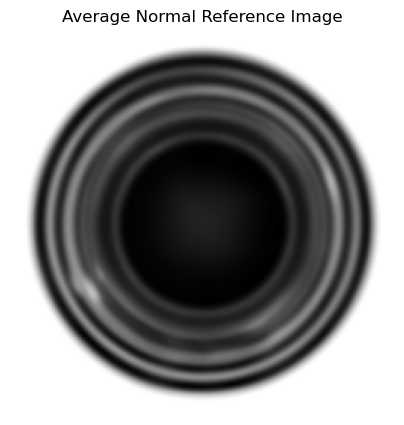

Saved reference image: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\baseline_detection\normal_reference.png


In [4]:
train_image_paths = train_df["image_path"].tolist()
reference_image = build_reference_image(train_image_paths, size=(256, 256))

print("Reference image shape:", reference_image.shape)
print("Reference min/max:", reference_image.min(), reference_image.max())

plt.figure(figsize=(5, 5))
plt.imshow(reference_image, cmap="gray")
plt.title("Average Normal Reference Image")
plt.axis("off")
plt.show()

reference_path = OUTPUT_DIR / "normal_reference.png"
cv2.imwrite(str(reference_path), reference_image.astype(np.uint8))
print("Saved reference image:", reference_path)

## Calculate Training Scores

We score normal training images against the reference image.

Then we choose a threshold from these normal scores. If a future image has a much higher score, it may be defective.

Train score min: 27.39
Train score mean: 45.52
Train score max: 83.42
Threshold percentile: 95.0
Threshold: 61.99


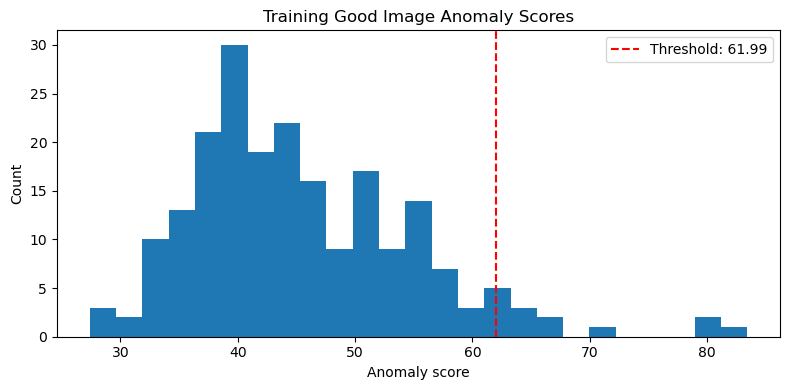

In [5]:
train_scores = []

for image_path in train_df["image_path"]:
    image_bgr = load_image_bgr(image_path)
    diff = anomaly_map(image_bgr, reference_image, size=(256, 256))
    score = anomaly_score(diff, percentile=99.0)
    train_scores.append(score)

threshold_percentile = 95.0
threshold = threshold_from_scores(train_scores, percentile=threshold_percentile)

print("Train score min:", round(min(train_scores), 2))
print("Train score mean:", round(float(np.mean(train_scores)), 2))
print("Train score max:", round(max(train_scores), 2))
print("Threshold percentile:", threshold_percentile)
print("Threshold:", round(threshold, 2))

plt.figure(figsize=(8, 4))
plt.hist(train_scores, bins=25)
plt.axvline(threshold, color="red", linestyle="--", label=f"Threshold: {threshold:.2f}")
plt.title("Training Good Image Anomaly Scores")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

## Score Test Images

Now we score every test image and predict:

- `0` = good
- `1` = defective

In [6]:
results_df = score_dataframe(test_df, reference_image, threshold)

results_df[["label", "target_name", "anomaly_score", "prediction_name"]].head(10)

,label,target_name,anomaly_score,prediction_name
0,good,good,59.052139,good
1,good,good,28.728897,good
2,good,good,51.760624,good
3,good,good,40.923981,good
4,good,good,33.384781,good
5,good,good,41.319168,good
6,good,good,44.745102,good
7,good,good,55.032749,good
8,good,good,44.893600,good
9,good,good,41.842106,good


## Evaluate Good vs Defective

These metrics show how the baseline performs on test images.

In [7]:
y_true = results_df["target"].tolist()
y_pred = results_df["prediction"].tolist()

metrics = evaluate_binary_predictions(y_true, y_pred)

try:
    metrics["roc_auc"] = round(float(roc_auc_score(y_true, results_df["anomaly_score"])), 4)
except ValueError:
    metrics["roc_auc"] = None

metrics

{'accuracy': 0.7711,
 'precision': 1.0,
 'recall': 0.6984,
 'f1_score': 0.8224,
 'confusion_matrix': [[20, 0], [19, 44]],
 'roc_auc': 0.9206}

## Threshold Sensitivity

Different threshold percentiles create different precision/recall tradeoffs.

In manufacturing, this matters because missing a defect and falsely rejecting a good product have different business costs.

In [8]:
threshold_rows = []

for percentile in [90, 95, 97, 99]:
    candidate_threshold = threshold_from_scores(train_scores, percentile=percentile)
    candidate_predictions = [predict_from_score(score, candidate_threshold) for score in results_df["anomaly_score"]]
    candidate_metrics = evaluate_binary_predictions(y_true, candidate_predictions)
    threshold_rows.append({
        "threshold_percentile": percentile,
        "threshold": round(candidate_threshold, 2),
        "accuracy": candidate_metrics["accuracy"],
        "precision": candidate_metrics["precision"],
        "recall": candidate_metrics["recall"],
        "f1_score": candidate_metrics["f1_score"],
        "confusion_matrix": candidate_metrics["confusion_matrix"],
    })

threshold_sensitivity_df = pd.DataFrame(threshold_rows)
threshold_sensitivity_df

,threshold_percentile,threshold,accuracy,precision,recall,f1_score,confusion_matrix
0,90,57.42,0.8072,0.9434,0.7937,0.8621,"[[17, 3], [13, 50]]"
1,95,61.99,0.7711,1.0000,0.6984,0.8224,"[[20, 0], [19, 44]]"
2,97,64.78,0.7108,1.0000,0.6190,0.7647,"[[20, 0], [24, 39]]"
3,99,78.44,0.5181,1.0000,0.3651,0.5349,"[[20, 0], [40, 23]]"


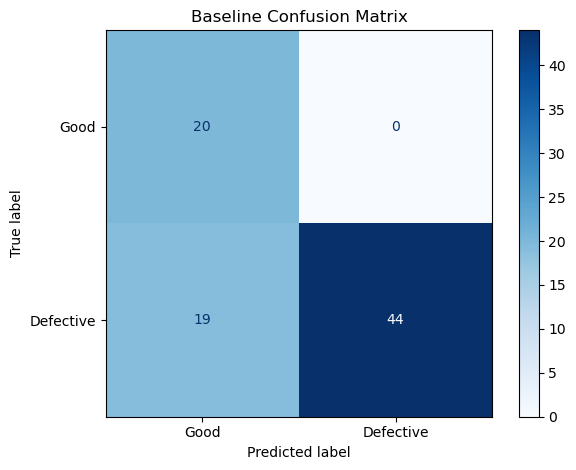

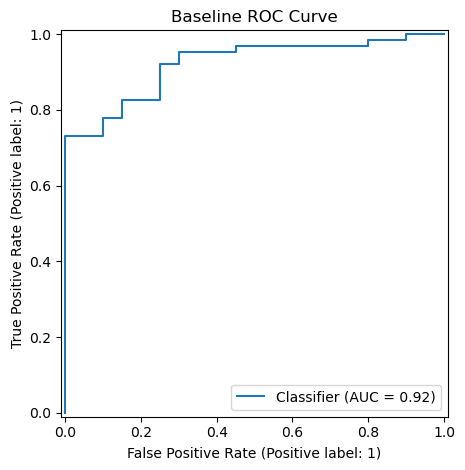

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Good", "Defective"],
    cmap="Blues",
)
plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_true, results_df["anomaly_score"])
plt.title("Baseline ROC Curve")
plt.tight_layout()
plt.show()

## Score Distribution By Defect Type

A useful baseline should generally give higher anomaly scores to defective images than good images.

C:\Users\HP\AppData\Local\Temp\ipykernel_18996\3126845923.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(score_groups, labels=labels)


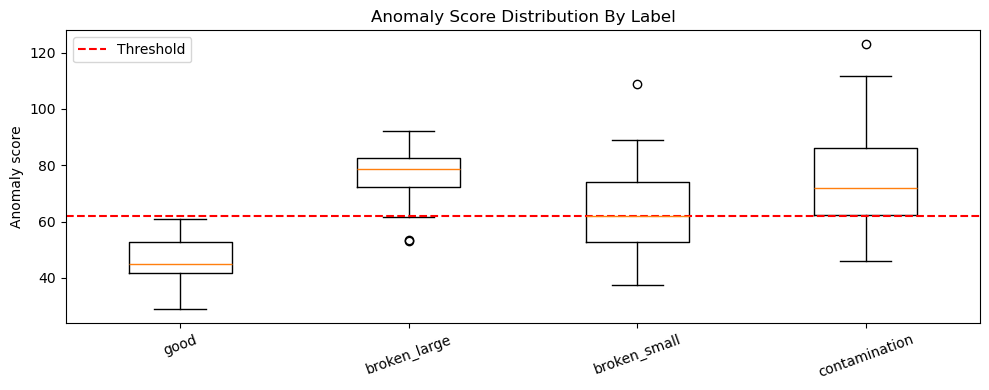

In [10]:
labels = results_df["label"].unique().tolist()
score_groups = [results_df[results_df["label"] == label]["anomaly_score"] for label in labels]

plt.figure(figsize=(10, 4))
plt.boxplot(score_groups, labels=labels)
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.xticks(rotation=20)
plt.ylabel("Anomaly score")
plt.title("Anomaly Score Distribution By Label")
plt.legend()
plt.tight_layout()
plt.show()

## Label-Level Summary

This shows how many images were predicted good/defective for each true label.

In [11]:
label_summary = (
    results_df
    .groupby(["label", "target_name", "prediction_name"])
    .size()
    .reset_index(name="count")
)

label_summary

,label,target_name,prediction_name,count
0,broken_large,defective,defective,17
1,broken_large,defective,good,3
2,broken_small,defective,defective,11
3,broken_small,defective,good,11
4,contamination,defective,defective,16
5,contamination,defective,good,5
6,good,good,good,20


## Visualize Heatmap For One Defective Image

The difference map is a simple baseline heatmap. It shows where the image differs from normal reference.

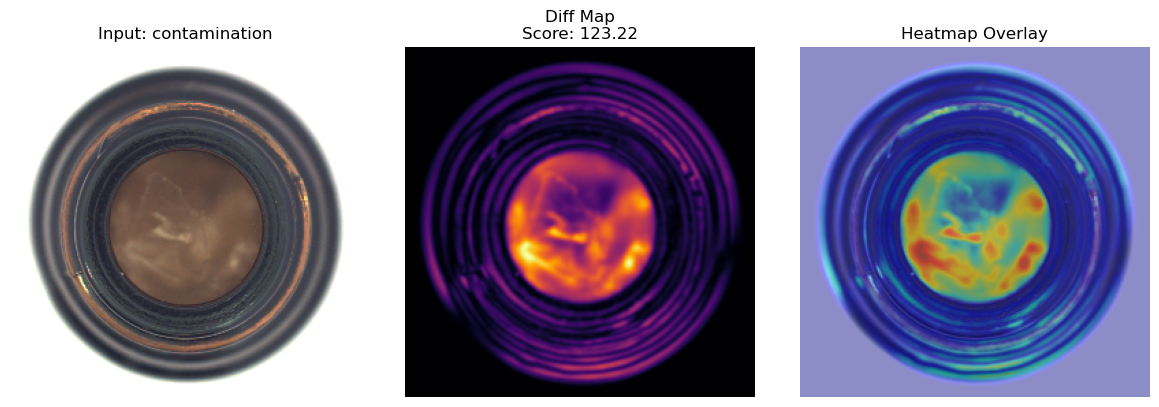

Saved heatmap: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\heatmaps\baseline\baseline_contamination_006.png


In [12]:
def show_baseline_heatmap(row):
    image_bgr = load_image_bgr(row["image_path"])
    image_rgb = cv2.cvtColor(cv2.resize(image_bgr, (256, 256)), cv2.COLOR_BGR2RGB)
    diff = anomaly_map(image_bgr, reference_image, size=(256, 256))
    overlay_bgr = heatmap_overlay(image_bgr, diff, alpha=0.45)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image_rgb)
    axes[0].set_title(f"Input: {row['label']}")
    axes[1].imshow(diff, cmap="inferno")
    axes[1].set_title(f"Diff Map\nScore: {row['anomaly_score']:.2f}")
    axes[2].imshow(overlay_rgb)
    axes[2].set_title("Heatmap Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    output_path = HEATMAP_DIR / f"baseline_{row['label']}_{Path(row['image_path']).stem}.png"
    cv2.imwrite(str(output_path), overlay_bgr)
    print("Saved heatmap:", output_path)


sample_defect = results_df[results_df["target"] == 1].sort_values("anomaly_score", ascending=False).iloc[0]
show_baseline_heatmap(sample_defect)

## Compare Good vs Defective Examples

This helps understand baseline behavior visually.

Label: good
True: good
Predicted: good
Score: 61.06


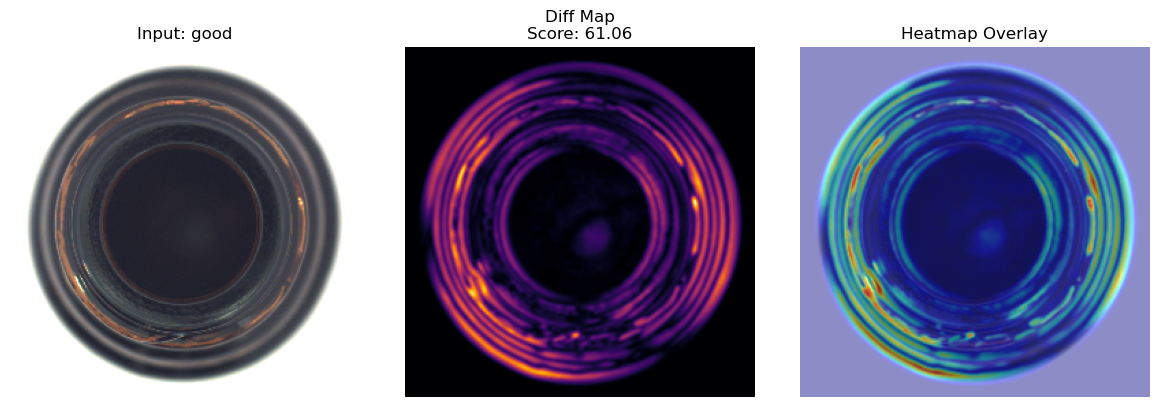

Saved heatmap: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\heatmaps\baseline\baseline_good_010.png
------------------------------------------------------------
Label: contamination
True: defective
Predicted: defective
Score: 123.22


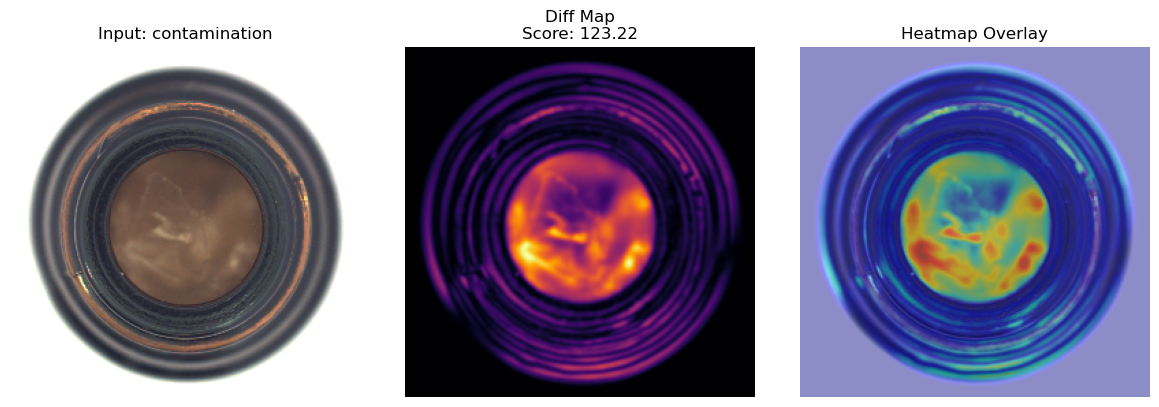

Saved heatmap: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\heatmaps\baseline\baseline_contamination_006.png
------------------------------------------------------------


In [13]:
sample_good = results_df[results_df["target"] == 0].sort_values("anomaly_score", ascending=False).iloc[0]
sample_defect = results_df[results_df["target"] == 1].sort_values("anomaly_score", ascending=False).iloc[0]

for row in [sample_good, sample_defect]:
    print("Label:", row["label"])
    print("True:", row["target_name"])
    print("Predicted:", row["prediction_name"])
    print("Score:", round(row["anomaly_score"], 2))
    show_baseline_heatmap(row)
    print("-" * 60)

## Save Baseline Results

Save predictions and metrics for documentation and comparison with Anomalib.

In [14]:
results_path = REPORT_DIR / "baseline_detection_results.csv"
metrics_path = REPORT_DIR / "baseline_detection_metrics.json"
summary_path = REPORT_DIR / "baseline_detection_label_summary.csv"
threshold_sensitivity_path = REPORT_DIR / "baseline_threshold_sensitivity.csv"

results_df.to_csv(results_path, index=False)
label_summary.to_csv(summary_path, index=False)
threshold_sensitivity_df.to_csv(threshold_sensitivity_path, index=False)

pd.Series(metrics).to_json(metrics_path, indent=2)

print("Saved results:", results_path)
print("Saved metrics:", metrics_path)
print("Saved label summary:", summary_path)
print("Saved threshold sensitivity:", threshold_sensitivity_path)

Saved results: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\baseline_detection_results.csv
Saved metrics: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\baseline_detection_metrics.json
Saved label summary: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\baseline_detection_label_summary.csv
Saved threshold sensitivity: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\baseline_threshold_sensitivity.csv


## Baseline Limitations

This baseline is intentionally simple. It may fail when:

- product position changes
- lighting changes strongly
- normal product variation is high
- defects are subtle
- the background changes

That is why the next step is a professional anomaly detection model using Anomalib.

## Summary

You built a simple defect detection baseline:

- created a normal reference image
- calculated anomaly scores
- selected a threshold from normal training images
- predicted good vs defective
- evaluated accuracy, precision, recall, F1, and ROC-AUC
- generated baseline heatmaps
- saved results for reporting

Next notebook: `07_anomalib_model_training.ipynb`.